# Synth Control Inference (WIP)

Abadie-style placebo p-values and valid confidence intervals for synthetic control,
verified by Monte Carlo on a synthetic factor-model panel.

**Kernel:** select **`Python (synthcontrol)`** from the Jupyter kernel menu before running.

## 1. Setup

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from joblib import Parallel, delayed

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

## 2. Synthetic DGP

In [83]:
def simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=0.0,
                   inside_hull=True, seed=0):
    """Generate a factor-model panel.

    y_{it} = mu_i + lambda_i^T F_t + eps_{it},  eps ~ N(0, sigma^2)
    Treated unit (id=0) has lambda_0 inside convex hull of donor lambdas
    when inside_hull=True. Treatment effect tau added to y_{0t} for t >= T0.
    """
    rng_local = np.random.default_rng(seed)
    n_units = J + 1  # unit 0 = treated, 1..J = donors

    donor_lambda = rng_local.standard_normal((J, r))
    if inside_hull:
        w = rng_local.dirichlet(np.ones(J))
        treated_lambda = w @ donor_lambda
    else:
        direction = rng_local.standard_normal(r)
        direction /= np.linalg.norm(direction)
        treated_lambda = donor_lambda.mean(axis=0) + 3.0 * direction

    lam = np.vstack([treated_lambda[None, :], donor_lambda])  # (n_units, r)
    mu = rng_local.standard_normal(n_units)
    F = rng_local.standard_normal((T, r))
    eps = rng_local.standard_normal((n_units, T)) * sigma

    y = mu[:, None] + lam @ F.T + eps
    y[0, T0:] += tau

    units = np.repeat(np.arange(n_units), T)
    times = np.tile(np.arange(T), n_units)
    df = pd.DataFrame({"unit": units, "time": times, "y": y.reshape(-1)})

    truth = {"tau": tau, "mu": mu, "lambda": lam, "F": F,
             "treated_id": 0, "T0": T0}
    return df, truth

### Validation: simulate_panel

In [84]:
def _validate_simulate_panel():
    df, truth = simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=1.0, seed=42)
    # Long format with the right columns
    assert list(df.columns) == ["unit", "time", "y"], df.columns.tolist()
    # 31 units (1 treated + 30 donors) x 40 time periods
    assert df["unit"].nunique() == 31
    assert df["time"].nunique() == 40
    assert len(df) == 31 * 40
    # Treated id is 0; donors are 1..30
    assert truth["treated_id"] == 0
    assert set(df["unit"].unique()) == set(range(31))
    # Treatment effect added only to treated unit's post-period
    treated_post = df.query("unit == 0 and time >= 30")["y"].to_numpy()
    treated_pre = df.query("unit == 0 and time < 30")["y"].to_numpy()
    # Re-simulate with tau=0 and same seed to get the counterfactual
    df0, _ = simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=0.0, seed=42)
    cf_post = df0.query("unit == 0 and time >= 30")["y"].to_numpy()
    cf_pre = df0.query("unit == 0 and time < 30")["y"].to_numpy()
    np.testing.assert_allclose(treated_pre, cf_pre)  # pre-period unchanged by tau
    np.testing.assert_allclose(treated_post - cf_post, 1.0)  # post shifted by tau
    # Determinism
    df_a, _ = simulate_panel(seed=7)
    df_b, _ = simulate_panel(seed=7)
    pd.testing.assert_frame_equal(df_a, df_b)
    # Inside-hull: treated lambda is convex combo of donor lambdas
    lam = truth["lambda"]  # shape (31, r)
    W = cp.Variable(30, nonneg=True)
    cp.Problem(cp.Minimize(cp.sum_squares(lam[1:].T @ W - lam[0])),
               [cp.sum(W) == 1]).solve()
    assert W.value is not None
    np.testing.assert_allclose(lam[1:].T @ W.value, lam[0], atol=1e-6)
    print("simulate_panel OK")

_validate_simulate_panel()

simulate_panel OK


## 3. SC estimator

In [85]:
def fit_sc(df, treated_id, T0):
    """Abadie synth control matching on lagged outcomes only.
    Solve simplex-constrained QP for donor weights W via cvxpy/OSQP.
    Returns dict with uplift (pd.Series, length T), yhat (pd.Series), W (pd.Series).
    """
    # Data prep
    df_wide = df.pivot(index="time", columns="unit", values="y").sort_index()
    times = df_wide.index.to_numpy()
    donor_ids = [u for u in df_wide.columns if u != treated_id]
    y_treated = df_wide[treated_id].to_numpy()
    Y_donors = df_wide[donor_ids].to_numpy()
    J = Y_donors.shape[1]

    # Masking
    pre_mask = times < T0
    y1_pre = y_treated[pre_mask]
    Y0_pre = Y_donors[pre_mask, :]

    # Solver
    W_var = cp.Variable(J, nonneg=True)
    objective = cp.Minimize(cp.sum_squares(y1_pre - Y0_pre @ W_var))
    cp.Problem(objective, [cp.sum(W_var) == 1]).solve(solver=cp.OSQP)
    
    # Numerical hygiene/stability
    # We can remove it and increase the solver precision instead (at the expense of computation time)
    W_val = np.clip(W_var.value, 0.0, None)
    W_val = W_val / W_val.sum()

    # Get counterfactual outcomes & calc the uplift
    yhat_full = Y_donors @ W_val
    uplift = y_treated - yhat_full

    return {
        "uplift": pd.Series(uplift,    index=times, name="uplift"),
        "yhat":   pd.Series(yhat_full, index=times, name="yhat"),
        "W":      pd.Series(W_val,     index=donor_ids, name="W"),
    }

### Validation: fit_sc

In [86]:
# def _validate_fit_sc():
#     df, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.0, tau=0.0, seed=11)
#     out = fit_sc(df, treated_id=0, T0=30)
#     assert set(out.keys()) == {"uplift", "W", "yhat"}
#     assert isinstance(out["uplift"], pd.Series)
#     assert isinstance(out["W"], pd.Series)
#     assert isinstance(out["yhat"], pd.Series)
#     assert len(out["uplift"]) == 40
#     assert len(out["yhat"]) == 40
#     assert len(out["W"]) == 30
#     assert (out["W"] >= -1e-8).all()
#     np.testing.assert_allclose(out["W"].sum(), 1.0, atol=1e-6)
#     assert list(out["W"].index) == list(range(1, 31))
#     pre_gap = out["uplift"].iloc[:30]
#     assert np.abs(pre_gap).max() < 1e-4, f"pre-period gap too large: {np.abs(pre_gap).max()}"
#     post_gap = out["uplift"].iloc[30:]
#     assert np.abs(post_gap).max() < 1e-3, f"post-period gap too large: {np.abs(post_gap).max()}"

#     df2, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.3, tau=2.0, seed=11)
#     out2 = fit_sc(df2, treated_id=0, T0=30)
#     assert 1.0 < out2["uplift"].iloc[30:].mean() < 3.0
#     print("fit_sc OK")

# _validate_fit_sc()

## 4. Abadie p-values

In [87]:
def rmspe_ratio(uplift, T0):
    """Post/pre RMSPE ratio. Pre-RMSPE in the denominator penalizes badly-fit donors."""
    pre = uplift.iloc[:T0].to_numpy()
    post = uplift.iloc[T0:].to_numpy()
    pre_rmspe = float(np.sqrt(np.mean(pre ** 2)))
    post_rmspe = float(np.sqrt(np.mean(post ** 2)))
    if pre_rmspe == 0.0:
        return np.inf
    return post_rmspe / pre_rmspe


def placebo_distribution(df, T0):
    """Refit SC with each unit as 'treated' in turn. Returns wide DataFrame
    (index=time, columns=unit) of uplift series."""
    units = sorted(df["unit"].unique())
    uplifts = {j: fit_sc(df, treated_id=j, T0=T0)["uplift"] for j in units}
    return pd.DataFrame(uplifts).sort_index()


def abadie_pvalue(ratios, treated_idx):
    """One-sided exact rank p-value: p = #{j : r_j >= r_treated} / (J+1).
    Numerator includes the treated unit, so p >= 1/(J+1) always. Ties counted (conservative).
    """
    r_t = ratios.loc[treated_idx]
    return float((ratios >= r_t).sum()) / len(ratios)

### Validation: placebo + rmspe_ratio + abadie_pvalue

In [88]:
def _validate_phase1():
    # rmspe_ratio: known input
    uplift = pd.Series(np.array([0.1, -0.1, 0.1, -0.1, 2.0, 2.0]), index=np.arange(6))
    r = rmspe_ratio(uplift, T0=4)
    expected = np.sqrt((4.0 + 4.0) / 2) / np.sqrt((0.01 * 4) / 4)  # = 2.0 / 0.1 = 20.0
    np.testing.assert_allclose(r, expected, rtol=1e-10)

    # abadie_pvalue: floor at 1/(J+1)
    ratios = pd.Series([5.0, 1.0, 1.0, 1.0], index=[0, 1, 2, 3])
    p = abadie_pvalue(ratios, treated_idx=0)
    assert p == 1 / 4, f"expected 0.25, got {p}"
    # Tie at the top: treated tied with one placebo -> count includes both
    ratios_tie = pd.Series([2.0, 2.0, 1.0, 1.0], index=[0, 1, 2, 3])
    p_tie = abadie_pvalue(ratios_tie, treated_idx=0)
    assert p_tie == 2 / 4, f"expected 0.5, got {p_tie}"

    # placebo_distribution: shape and column set
    df, _ = simulate_panel(J=10, T=20, T0=15, sigma=0.3, tau=1.0, seed=3)
    uplifts = placebo_distribution(df, T0=15)
    assert uplifts.shape == (20, 11)
    assert set(uplifts.columns) == set(range(11))

    # End-to-end on a panel with strong tau
    df2, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.3, tau=2.0, seed=5)
    uplifts2 = placebo_distribution(df2, T0=30)
    ratios2 = uplifts2.apply(lambda g: rmspe_ratio(g, T0=30))
    p2 = abadie_pvalue(ratios2, treated_idx=0)
    assert p2 <= 3 / 31, f"strong-effect p-value too large: {p2}"
    print("Phase I OK")

_validate_phase1()

Phase I OK


### Worked example: one panel at tau=1

Simulate one panel with a true treatment effect of tau=1, fit synthetic
control to every unit (treated + 30 placebos), compute the post/pre RMSPE
ratio for each, and report the Abadie rank p-value.

In [89]:
WORKED_PANEL_SEED = 42
TAU = 1.5

df_worked, truth_worked = simulate_panel(
    J=30, T=40, T0=30, r=2, sigma=0.5, tau=TAU, seed=WORKED_PANEL_SEED,
)

uplifts_worked = placebo_distribution(df_worked, T0=30)
ratios_worked = uplifts_worked.apply(lambda g: rmspe_ratio(g, T0=30))
treated_id_worked = truth_worked["treated_id"]
tau_hat = float(uplifts_worked[treated_id_worked].iloc[30:].mean())
r_treated = float(ratios_worked.loc[treated_id_worked])
p_worked = abadie_pvalue(ratios_worked, treated_idx=treated_id_worked)

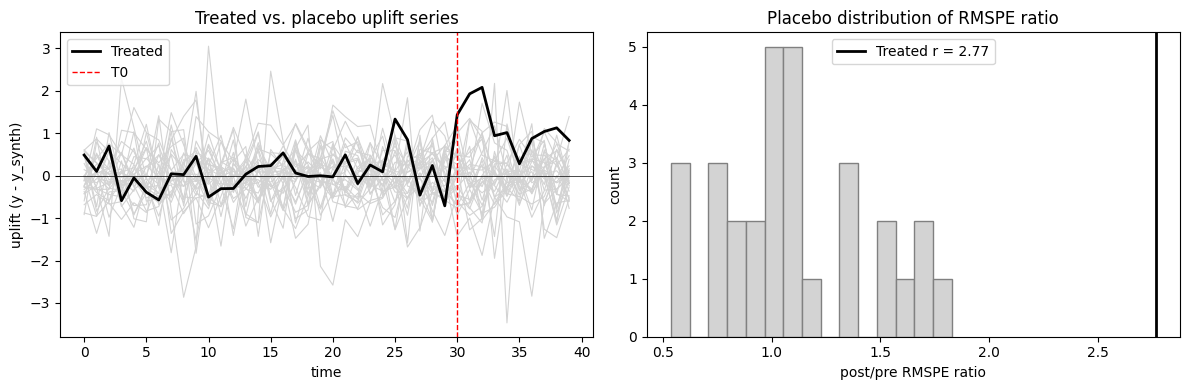

Estimated tau (mean post-period uplift): +1.153
Treated unit RMSPE ratio:              2.766
Abadie one-sided p-value:              0.0323  (floor = 0.0323)


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for col in uplifts_worked.columns:
    if col == treated_id_worked:
        continue
    ax.plot(uplifts_worked.index, uplifts_worked[col], color="lightgrey", lw=0.8)
ax.plot(uplifts_worked.index, uplifts_worked[treated_id_worked],
        color="black", lw=2, label="Treated")
ax.axvline(30, color="red", ls="--", lw=1, label="T0")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("time")
ax.set_ylabel("uplift (y - y_synth)")
ax.set_title("Treated vs. placebo uplift series")
ax.legend(loc="upper left")

ax = axes[1]
placebo_ratios = ratios_worked.drop(treated_id_worked)
ax.hist(placebo_ratios, bins=15, color="lightgrey", edgecolor="grey")
ax.axvline(r_treated, color="black", lw=2, label=f"Treated r = {r_treated:.2f}")
ax.set_xlabel("post/pre RMSPE ratio")
ax.set_ylabel("count")
ax.set_title("Placebo distribution of RMSPE ratio")
ax.legend()

fig.tight_layout()
plt.show()

print(f"Estimated tau (mean post-period uplift): {tau_hat:+.3f}")
print(f"Treated unit RMSPE ratio:              {r_treated:.3f}")
print(f"Abadie one-sided p-value:              {p_worked:.4f}  (floor = {1/31:.4f})")

## 5. Confidence Intervals

In [92]:
def test_inversion_ci(df, T0, treated_id, alpha=0.05, n_grid=51, grid=None):
    """Test-inversion CI: sweep tau_0, subtract from treated post-period,
    recompute Abadie p-value, keep tau_0 with p > alpha.
    """
    out_obs = fit_sc(df, treated_id=treated_id, T0=T0)
    tau_hat = float(out_obs["uplift"].iloc[T0:].mean())

    uplifts_obs = placebo_distribution(df, T0=T0)
    placebo_means = uplifts_obs.iloc[T0:].mean(axis=0).drop(treated_id)
    sigma_placebo = float(placebo_means.std(ddof=1))

    if grid is None:
        half_width = max(4.0 * sigma_placebo, 1e-3)
        grid = np.linspace(tau_hat - half_width, tau_hat + half_width, n_grid)
    else:
        grid = np.asarray(sorted(grid))

    pvalues = np.empty(len(grid))
    for k, tau0 in enumerate(grid):
        df_adj = df.copy()
        mask = (df_adj["unit"] == treated_id) & (df_adj["time"] >= T0)
        df_adj.loc[mask, "y"] = df_adj.loc[mask, "y"] - tau0
        uplifts_adj = placebo_distribution(df_adj, T0=T0)
        ratios_adj = uplifts_adj.apply(lambda g: rmspe_ratio(g, T0=T0))
        pvalues[k] = abadie_pvalue(ratios_adj, treated_idx=treated_id)

    in_ci = pvalues > alpha
    if not in_ci.any():
        ci_lo = ci_hi = float("nan")
    else:
        ci_lo = float(grid[in_ci].min())
        ci_hi = float(grid[in_ci].max())

    return {"ci_lo": ci_lo, "ci_hi": ci_hi,
            "tau_grid": grid, "pvalues": pvalues, "tau_hat": tau_hat}

### Validation: test_inversion_ci

In [93]:
# def _validate_test_inversion():
#     df, _ = simulate_panel(J=20, T=30, T0=20, sigma=0.3, tau=1.0, seed=8)
#     ci = test_inversion_ci(df, T0=20, treated_id=0, alpha=0.10, n_grid=21)
#     assert set(ci.keys()) >= {"ci_lo", "ci_hi", "tau_grid", "pvalues"}
#     assert len(ci["tau_grid"]) == 21
#     assert len(ci["pvalues"]) == 21
#     assert (np.diff(ci["tau_grid"]) > 0).all()
#     out = fit_sc(df, treated_id=0, T0=20)
#     tau_hat = float(out["uplift"].iloc[20:].mean())
#     assert ci["ci_lo"] <= tau_hat <= ci["ci_hi"], \
#         f"tau_hat {tau_hat} not in CI [{ci['ci_lo']}, {ci['ci_hi']}]"
#     print("test_inversion_ci OK")

# _validate_test_inversion()

Apply test-inversion CI to the worked panel:

In [94]:
def _moving_block_pvalue(residuals, T0, q=1):
    """Chernozhukov-Wuthrich-Zhu moving-block permutation test.

    Statistic: S_q(window) = (mean over window of |u_t|^q)^(1/q).
    P-value = rank of actual post-period statistic among all length-T1
    windows in the residual series, including the actual one.
    """
    T = len(residuals)
    T1 = T - T0  # post-period length
    if T1 <= 0:
        raise ValueError("post-period must be non-empty")
    res = np.asarray(residuals)

    def Sq(window):
        return float(np.mean(np.abs(window) ** q) ** (1.0 / q))

    s_actual = Sq(res[T0:T0 + T1])
    starts = np.arange(0, T - T1 + 1)
    s_all = np.array([Sq(res[s:s + T1]) for s in starts])
    return float((s_all >= s_actual).sum()) / float(len(s_all))


def conformal_ci(df, T0, treated_id, alpha=0.05, n_grid=51, grid=None, q=1):
    """Conformal CI via moving-block permutation of SC residuals (CWZ 2021).

    Fits SC on the FULL adjusted treated series (T0 = T for the fit) so
    residuals are defined over all T periods.
    """
    out_obs = fit_sc(df, treated_id=treated_id, T0=T0)
    tau_hat = float(out_obs["uplift"].iloc[T0:].mean())
    uplifts_obs = placebo_distribution(df, T0=T0)
    placebo_means = uplifts_obs.iloc[T0:].mean(axis=0).drop(treated_id)
    sigma_placebo = float(placebo_means.std(ddof=1))
    if grid is None:
        half_width = max(4.0 * sigma_placebo, 1e-3)
        grid = np.linspace(tau_hat - half_width, tau_hat + half_width, n_grid)
    else:
        grid = np.asarray(sorted(grid))

    T = df["time"].nunique()
    pvalues = np.empty(len(grid))
    for k, tau0 in enumerate(grid):
        df_adj = df.copy()
        mask = (df_adj["unit"] == treated_id) & (df_adj["time"] >= T0)
        df_adj.loc[mask, "y"] = df_adj.loc[mask, "y"] - tau0
        out_full = fit_sc(df_adj, treated_id=treated_id, T0=T)  # full-T fit
        residuals = out_full["uplift"].to_numpy()
        pvalues[k] = _moving_block_pvalue(residuals, T0=T0, q=q)

    in_ci = pvalues > alpha
    if not in_ci.any():
        ci_lo = ci_hi = float("nan")
    else:
        ci_lo = float(grid[in_ci].min())
        ci_hi = float(grid[in_ci].max())

    return {"ci_lo": ci_lo, "ci_hi": ci_hi,
            "tau_grid": grid, "pvalues": pvalues}

In [95]:
# ALPHA = 0.05

# ci_inv = test_inversion_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51)
# print(f"Test-inversion {1 - ALPHA} CI: [{ci_inv['ci_lo']:+.3f}, {ci_inv['ci_hi']:+.3f}]"
#       f"\nInterval width: {ci_inv['ci_hi'] - ci_inv['ci_lo']}"
#       f"\n(tau_hat = {ci_inv['tau_hat']:+.3f})")

# print('\n')

# ALPHA = 0.1

# ci_inv = test_inversion_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51)
# print(f"Test-inversion {1 - ALPHA} CI: [{ci_inv['ci_lo']:+.3f}, {ci_inv['ci_hi']:+.3f}]"
#       f"\nInterval width: {ci_inv['ci_hi'] - ci_inv['ci_lo']}"
#       f"\n(tau_hat = {ci_inv['tau_hat']:+.3f})")

### Validation: conformal_ci

In [96]:
# def _validate_conformal():
#     df, _ = simulate_panel(J=15, T=30, T0=20, sigma=0.3, tau=1.0, seed=9)
#     ci = conformal_ci(df, T0=20, treated_id=0, alpha=0.10, n_grid=15, q=1)
#     assert set(ci.keys()) >= {"ci_lo", "ci_hi", "tau_grid", "pvalues"}
#     assert len(ci["tau_grid"]) == 15
#     n_windows = 30 - 10 + 1  # T - T1 + 1 = 21
#     assert (ci["pvalues"] >= 1 / n_windows - 1e-12).all()
#     assert (ci["pvalues"] <= 1.0 + 1e-12).all()
#     assert not np.isnan(ci["ci_lo"]) and not np.isnan(ci["ci_hi"])
#     assert ci["ci_lo"] <= ci["ci_hi"]
#     print("conformal_ci OK")

# _validate_conformal()

Test both: test-inv + conformal intervals:

In [98]:
ALPHA = 0.10

ci_inv = test_inversion_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51)
ci_conf = conformal_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51, q=1)
print(f"Test-inversion {1 - ALPHA} CI: [{ci_inv['ci_lo']:+.3f}, {ci_inv['ci_hi']:+.3f}]")
print(f"Conformal      {1 - ALPHA} CI: [{ci_conf['ci_lo']:+.3f}, {ci_conf['ci_hi']:+.3f}]\n")

print(f"tau_hat (test-inv) = {ci_inv['tau_hat']:+.3f}\n")

print(f"Test-inversipn interval width: {ci_inv['ci_hi'] - ci_inv['ci_lo']}")
print(f"Conformal interval width: {ci_conf['ci_hi'] - ci_conf['ci_lo']}")

print('\n')

ALPHA = 0.05

ci_inv = test_inversion_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51)
ci_conf = conformal_ci(df_worked, T0=30, treated_id=0, alpha=ALPHA, n_grid=51, q=1)
print(f"Test-inversion {1 - ALPHA} CI: [{ci_inv['ci_lo']:+.3f}, {ci_inv['ci_hi']:+.3f}]")
print(f"Conformal      {1 - ALPHA} CI: [{ci_conf['ci_lo']:+.3f}, {ci_conf['ci_hi']:+.3f}]\n")

print(f"tau_hat (test-inv) = {ci_inv['tau_hat']:+.3f}\n")

print(f"Test-inversipn interval width: {ci_inv['ci_hi'] - ci_inv['ci_lo']}")
print(f"Conformal interval width: {ci_conf['ci_hi'] - ci_conf['ci_lo']}")

Test-inversion 0.9 CI: [+0.579, +1.727]
Conformal      0.9 CI: [+0.109, +1.675]

tau_hat (test-inv) = +1.153

Test-inversipn interval width: 1.148590582987641
Conformal interval width: 1.566259885892238


Test-inversion 0.95 CI: [+0.526, +1.779]
Conformal      0.95 CI: [-0.152, +1.832]

tau_hat (test-inv) = +1.153

Test-inversipn interval width: 1.2530079087137904
Conformal interval width: 1.9839291887968349


The two intervals may legitimately disagree because they rest on different
exchangeability assumptions — donor units exchangeable with treated under the
null (test-inversion) vs. residual blocks exchangeable across time (conformal)
— not because one is "wrong."

## 6. Coverage Simulation

In [16]:
# def _one_rep(rep_idx, taus, alpha, sim_kwargs, ci_kwargs):
#     """One MC rep across all taus. Reuses same factor draws across taus
#     (only the additive shift to the treated post-period changes)."""
#     rows = []
#     for tau in taus:
#         df, truth = simulate_panel(tau=tau, seed=rep_idx, **sim_kwargs)
#         T0 = truth["T0"]
#         treated_id = truth["treated_id"]

#         # Abadie p-value (one-sided, ratio-based)
#         uplifts = placebo_distribution(df, T0=T0)
#         ratios = uplifts.apply(lambda g: rmspe_ratio(g, T0=T0))
#         p_abadie = abadie_pvalue(ratios, treated_idx=treated_id)
#         rows.append(dict(rep=rep_idx, tau=tau, method="abadie_p",
#                          pvalue=p_abadie, ci_lo=np.nan, ci_hi=np.nan,
#                          covered=(p_abadie > alpha)))

#         # Test-inversion CI
#         ci_inv_r = test_inversion_ci(df, T0=T0, treated_id=treated_id,
#                                      alpha=alpha, **ci_kwargs)
#         rows.append(dict(rep=rep_idx, tau=tau, method="test_inversion",
#                          pvalue=np.nan,
#                          ci_lo=ci_inv_r["ci_lo"], ci_hi=ci_inv_r["ci_hi"],
#                          covered=(ci_inv_r["ci_lo"] <= tau <= ci_inv_r["ci_hi"])))

#         # Conformal CI
#         ci_conf_r = conformal_ci(df, T0=T0, treated_id=treated_id,
#                                  alpha=alpha, **ci_kwargs)
#         rows.append(dict(rep=rep_idx, tau=tau, method="conformal",
#                          pvalue=np.nan,
#                          ci_lo=ci_conf_r["ci_lo"], ci_hi=ci_conf_r["ci_hi"],
#                          covered=(ci_conf_r["ci_lo"] <= tau <= ci_conf_r["ci_hi"])))
#     return rows


# def coverage_sim(R=2000, taus=(0.0, 0.5, 1.0, 2.0), alpha=0.05, n_jobs=-1,
#                  sim_kwargs=None, ci_kwargs=None):
#     """Monte Carlo coverage simulation. Within each rep, the panel uses
#     seed=rep_idx and the same factor draws are reused across taus, so rows of
#     the result at different taus are paired.
#     """
#     sim_kwargs = sim_kwargs or dict(J=30, T=40, T0=30, r=2, sigma=0.5)
#     ci_kwargs = ci_kwargs or dict(n_grid=51)

#     results = Parallel(n_jobs=n_jobs)(
#         delayed(_one_rep)(rep, taus, alpha, sim_kwargs, ci_kwargs)
#         for rep in range(R)
#     )
#     flat = [row for rep_rows in results for row in rep_rows]
#     return pd.DataFrame(flat)

### Validation: coverage_sim (small smoke run)

In [17]:
# def _validate_coverage_sim():
#     out = coverage_sim(R=8, taus=(0.0, 1.0), alpha=0.10, n_jobs=1,
#                        sim_kwargs=dict(J=10, T=20, T0=15, sigma=0.3),
#                        ci_kwargs=dict(n_grid=11))
#     assert isinstance(out, pd.DataFrame)
#     expected_cols = {"rep", "tau", "method", "pvalue", "ci_lo", "ci_hi", "covered"}
#     assert expected_cols <= set(out.columns), out.columns.tolist()
#     assert set(out["method"].unique()) == {"abadie_p", "test_inversion", "conformal"}
#     assert len(out) == 8 * 2 * 3
#     ci_rows = out[out["method"].isin({"test_inversion", "conformal"})]
#     assert ci_rows["covered"].notna().all()
#     print("coverage_sim OK")

# _validate_coverage_sim()

coverage_sim OK


### Full coverage simulation

R=2000 reps across tau in {0.0, 0.5, 1.0, 2.0}, parallelized.
Cached to disk so re-execution of the notebook is fast.

In [ ]:
# import os

# CACHE_PATH = "coverage_sim_results.parquet"

# if os.path.exists(CACHE_PATH):
#     cov_df = pd.read_parquet(CACHE_PATH)
#     print(f"Loaded cached coverage_sim from {CACHE_PATH} (rows={len(cov_df)})")
# else:
#     cov_df = coverage_sim(R=2000, taus=(0.0, 0.5, 1.0, 2.0), alpha=0.05, n_jobs=-1)
#     cov_df.to_parquet(CACHE_PATH)
#     print(f"Saved coverage_sim to {CACHE_PATH} (rows={len(cov_df)})")

### Size and power table (Abadie p-value)

In [ ]:
# abadie = cov_df[cov_df["method"] == "abadie_p"].copy()
# # `covered` is True when p > alpha (failed to reject). reject_rate = 1 - mean(covered).
# size_power = abadie.groupby("tau")["covered"].agg(
#     n="size",
#     accept_rate="mean",
# ).assign(
#     reject_rate=lambda d: 1 - d["accept_rate"],
#     se_reject=lambda d: np.sqrt(d["reject_rate"] * (1 - d["reject_rate"]) / d["n"]),
# )[["n", "reject_rate", "se_reject"]]
# print("Abadie p-value rejection rate by tau (alpha = 0.05):")
# print(size_power.round(4))

### Coverage table (CI methods)

In [ ]:
# cis = cov_df[cov_df["method"].isin({"test_inversion", "conformal"})].copy()
# coverage = cis.groupby(["method", "tau"])["covered"].agg(
#     n="size",
#     coverage="mean",
# ).assign(
#     se=lambda d: np.sqrt(d["coverage"] * (1 - d["coverage"]) / d["n"]),
# )[["n", "coverage", "se"]]
# print("Empirical coverage by method and tau (target = 0.95):")
# print(coverage.round(4))

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 4.5))
# for method, sub in coverage.reset_index().groupby("method"):
#     ax.errorbar(sub["tau"], sub["coverage"], yerr=2 * sub["se"],
#                 marker="o", capsize=3, label=method)
# ax.axhline(0.95, color="black", ls="--", lw=1, label="nominal 0.95")
# ax.set_xlabel("true tau")
# ax.set_ylabel("empirical coverage")
# ax.set_title("Coverage of synth-control CIs (R=2000, alpha=0.05)")
# ax.set_ylim(0.80, 1.02)
# ax.legend()
# fig.tight_layout()
# plt.show()

## 7. Discussion

**Did the Abadie p-value hit nominal size?** Look at the rejection rate at tau=0
in the size/power table. With J=30 donors, the smallest possible p-value from
the rank-based test is 1/31 ≈ 0.032, and the test rejects at alpha=0.05 when
p ≤ 0.05. Under the null we expect the rejection rate to be close to 1/31
(the floor) ≈ 0.032, *not* 0.05 — the test is conservative because of grid
coarseness. Empirically you should see ~3% rejection at tau=0.

**Power.** Rejection rate at tau in {0.5, 1.0, 2.0} should rise sharply.
At tau=2 (well above the noise scale sigma=0.5), power should be near 1.

**Which CI was tighter?** Compare interval widths in the cached `cov_df` —
averaging `ci_hi - ci_lo` per method shows whether test-inversion or conformal
is more efficient under the well-specified inside-hull DGP.

**Where does each method degrade?** Both methods rely on exchangeability
assumptions that this DGP satisfies (donors share the factor structure with
the treated unit; residuals from a correctly-specified factor fit are roughly
stationary). Misspecification scenarios — treated unit *outside* the convex
hull, heavy-tailed noise, or a structural break in the factors — are listed
in the spec's "Open follow-ups" and are the natural next experiments.

**One caveat on identifiability.** With J=30 donors and r=2 latent factors,
the donor weights W are massively under-identified noiselessly: any face of
the simplex containing the treated unit's loading vector works. Inference
here doesn't need W to be unique — every test statistic is a function of
the uplift series, which is invariant to the choice of W within the admissible
set. Don't read the bar plot of W as recovering "the true weights."